# Heart Disease Prediction using Logistic Regression

**Repositori**: Machine Learning  
**Topik**: Implementasi Logistic Regression untuk Prediksi Penyakit Jantung  
**Dataset**: `heart_disease_data.csv`  

---

## Pendahuluan
Proyek ini bertujuan untuk memprediksi keberadaan penyakit jantung pada pasien berdasarkan parameter medis (seperti usia, tekanan darah, kadar kolesterol, dll) menggunakan algoritma **Logistic Regression**. Logistic Regression adalah pilihan standar untuk tugas klasifikasi biner seperti ini.

### Alur Kerja (Pipeline):
1. **Data Acquisition**: Mengimpor dataset medis.
2. **Data Understanding**: Analisis statistik deskriptif dan korelasi.
3. **Data Preparation**: Penanganan *missing values* dan standarisasi fitur (*Scaling*).
4. **Modeling**: Training model Logistic Regression dengan hyperparameter tuning.
5. **Evaluation**: Evaluasi performa menggunakan Confusion Matrix dan metrik klasifikasi.

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_auc_score
)

warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)

## 1. Data Acquisition
Memuat dataset dengan validasi path untuk menghindari error pada environment berbeda.

In [2]:
DATA_PATH = '../../data/heart_disease_data.csv'

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f'Dataset tidak ditemukan di: {os.path.abspath(DATA_PATH)}')

df = pd.read_csv(DATA_PATH)
print(f'Dataset berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom')

Dataset berhasil dimuat: 303 baris, 14 kolom


## 2. Exploratory Data Analysis (EDA)
Memahami struktur data, distribusi, korelasi, dan deteksi anomali.

In [3]:
print('--- Informasi Dataset ---')
df.info()

print('\n--- 5 Baris Pertama ---')
display(df.head())

print('\n--- Statistik Deskriptif ---')
display(df.describe().T)

--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB

--- 5 Baris Pertama ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



--- Statistik Deskriptif ---


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


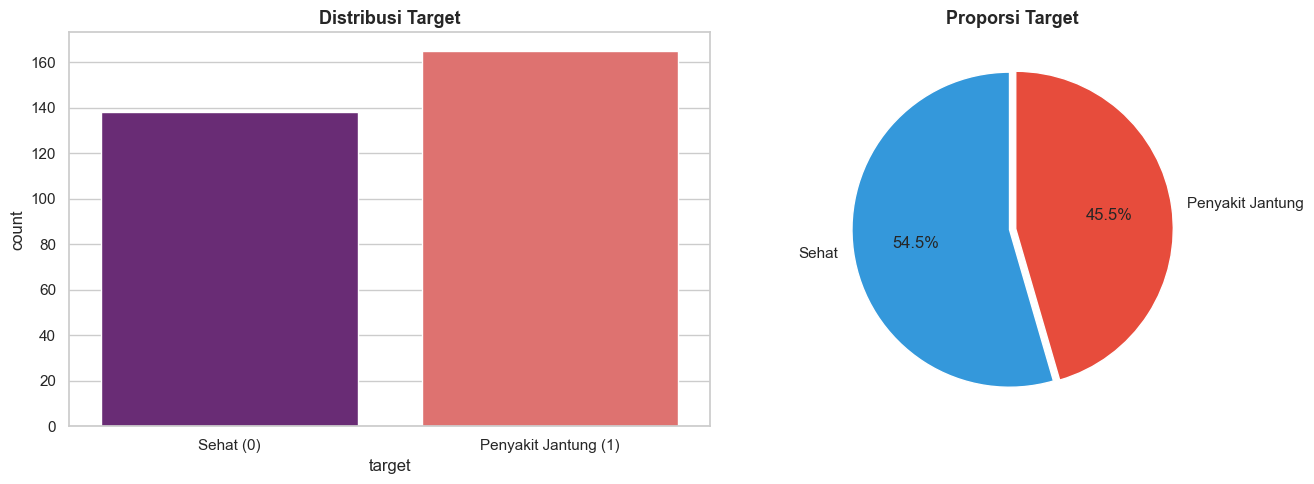

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x='target', data=df, palette='magma', ax=axes[0])
axes[0].set_title('Distribusi Target', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['Sehat (0)', 'Penyakit Jantung (1)'])

target_counts = df['target'].value_counts(normalize=True).mul(100).round(1)
axes[1].pie(
    target_counts, labels=['Sehat', 'Penyakit Jantung'],
    autopct='%1.1f%%', colors=['#3498db', '#e74c3c'], startangle=90,
    explode=(0.02, 0.02)
)
axes[1].set_title('Proporsi Target', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

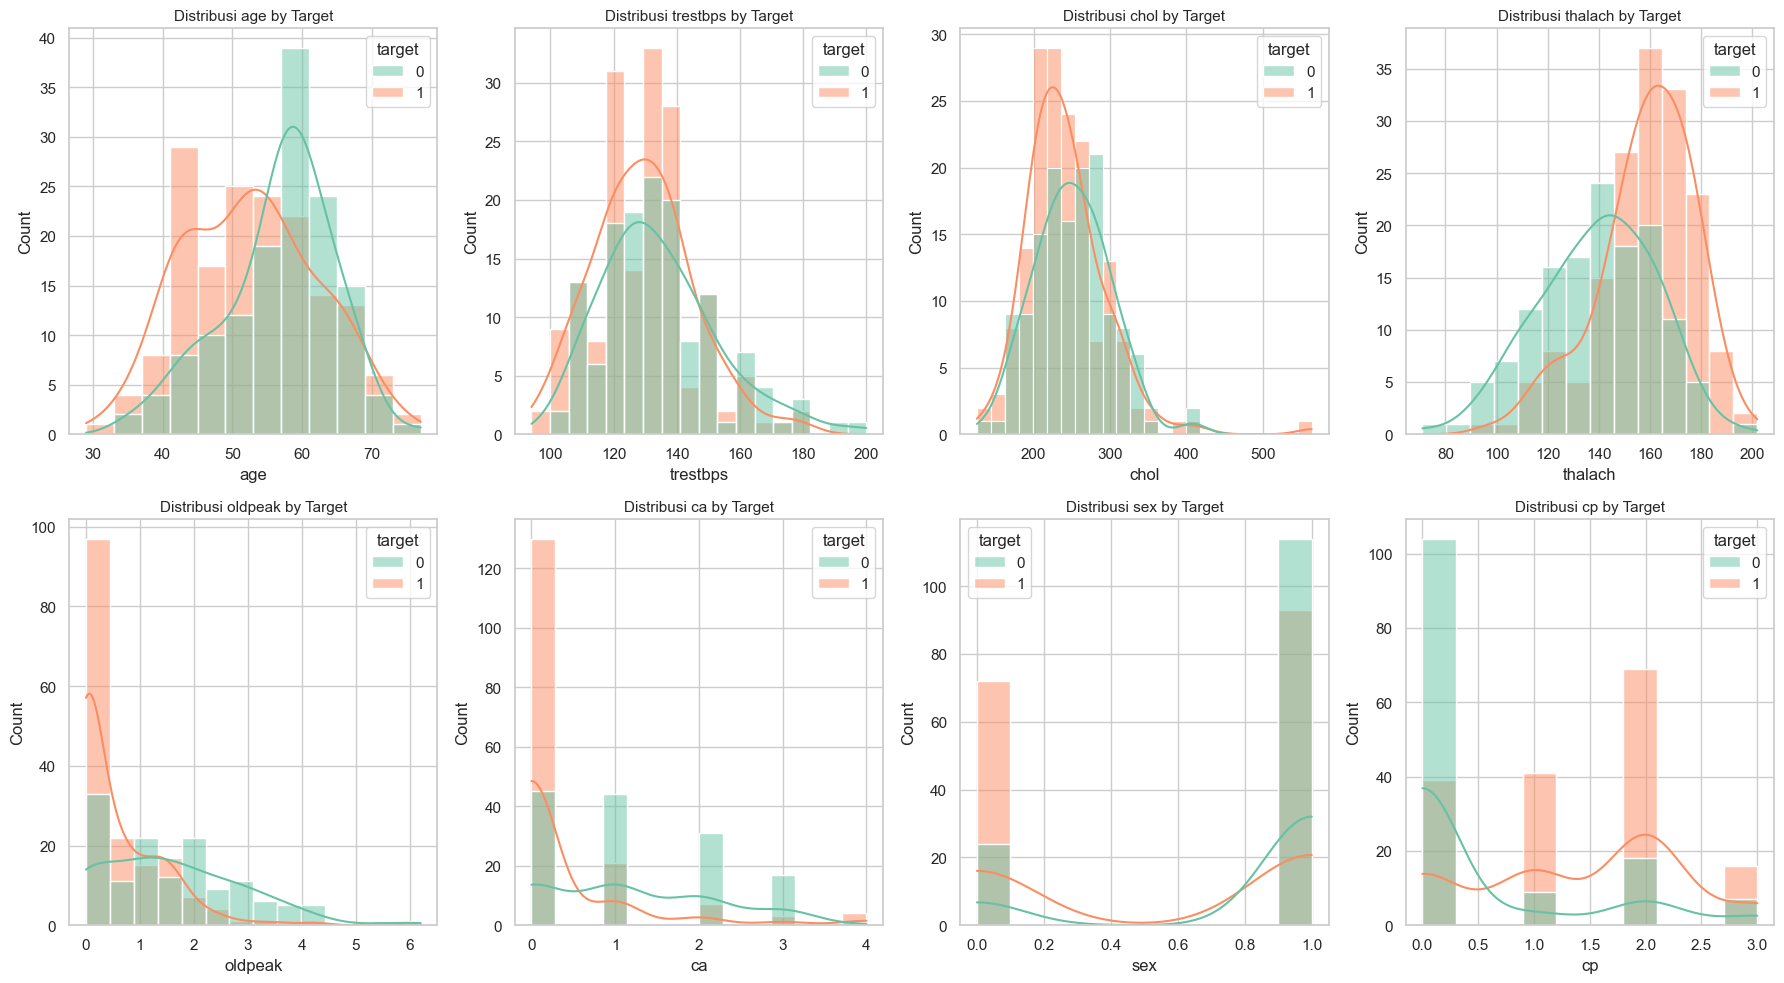

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
feature_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca', 'sex', 'cp']

for i, col in enumerate(feature_cols):
    row, col_idx = divmod(i, 4)
    sns.histplot(data=df, x=col, hue='target', kde=True, palette='Set2', ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'Distribusi {col} by Target', fontsize=11)

plt.tight_layout()
plt.show()

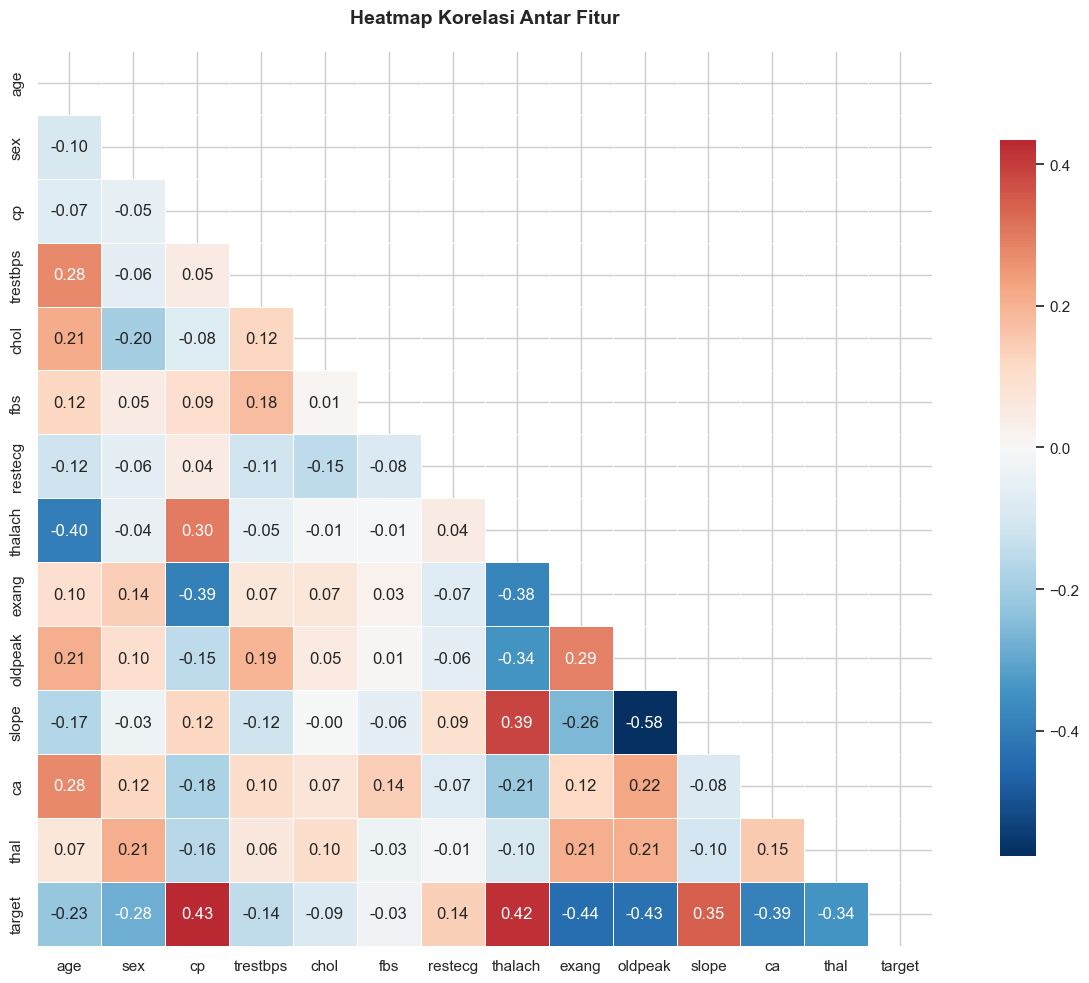

In [6]:
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 3. Data Preparation
Menangani *missing values* dan melakukan scaling fitur numerik.

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
print('--- Missing Values ---')
print(missing_report[missing_report['Missing'] > 0] if missing.any() else 'Tidak ada missing values.')

--- Missing Values ---
Tidak ada missing values.


In [8]:
if missing.any():
    num_cols = df.select_dtypes(include=[np.number]).columns.drop('target', errors='ignore')
    for col in num_cols:
        if df[col].isnull().any():
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f'Kolom "{col}": diisi dengan median = {median_val}')

print('\nMissing values setelah handling:')
print(df.isnull().sum().sum(), 'remaining')
print(f'Ukuran dataset akhir: {df.shape}')


Missing values setelah handling:
0 remaining
Ukuran dataset akhir: (303, 14)


In [9]:
X = df.drop('target', axis=1)
y = df['target']

print('Fitur (X):', list(X.columns))
print('Target (y) distribution:', y.value_counts().to_dict())

Fitur (X): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Target (y) distribution: {1: 165, 0: 138}


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test size : {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)')
print(f'Train target distribution: {pd.Series(y_train).value_counts().to_dict()}')
print(f'Test target distribution : {pd.Series(y_test).value_counts().to_dict()}')

Train size: 242 (79.9%)
Test size : 61 (20.1%)
Train target distribution: {1: 132, 0: 110}
Test target distribution : {1: 33, 0: 28}


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Feature scaling selesai menggunakan StandardScaler.')
print(f'Rata-rata setelah scaling (train): {X_train_scaled.mean(axis=0).round(4)[:5]} ...')
print(f'Std setelah scaling (train)      : {X_train_scaled.std(axis=0).round(4)[:5]} ...')

Feature scaling selesai menggunakan StandardScaler.
Rata-rata setelah scaling (train): [ 0.  0.  0.  0. -0.] ...
Std setelah scaling (train)      : [1. 1. 1. 1. 1.] ...


## 4. Model Training & Hyperparameter Tuning
Melatih Logistic Regression dengan `GridSearchCV` untuk menemukan hyperparameter optimal.

Parameter yang di-*tune*:
- `C`: Regularisasi (inverse). Semakin kecil, semakin kuat regularisasi.
- `solver`: Algoritma optimasi (`liblinear` cocok untuk dataset kecil).

In [12]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear'],
    'max_iter': [5000]
}

grid_search = GridSearchCV(
    LogisticRegression(random_state=42, penalty='l2'),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
print(f'Best parameters: {grid_search.best_params_}')
print(f'Best CV accuracy: {grid_search.best_score_:.4f}')

Best parameters: {'C': 0.01, 'max_iter': 5000, 'solver': 'liblinear'}
Best CV accuracy: 0.8258


In [13]:
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

## 5. Performance Evaluation
Evaluasi model menggunakan confusion matrix, classification report, dan AUC-ROC.

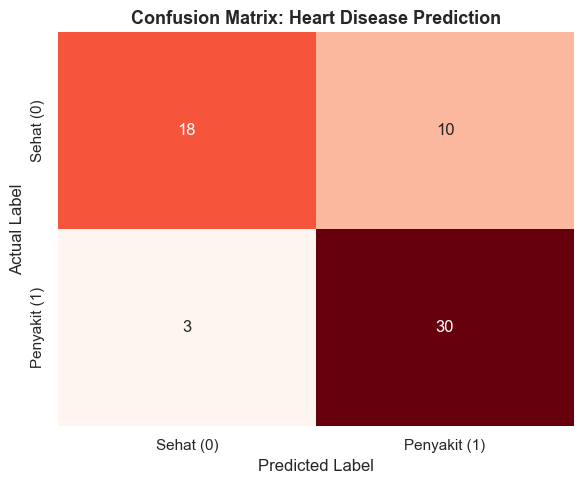

True Negatives : 18
False Positives: 10
False Negatives: 3
True Positives : 30


In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Reds', cbar=False,
    xticklabels=['Sehat (0)', 'Penyakit (1)'],
    yticklabels=['Sehat (0)', 'Penyakit (1)']
)
plt.title('Confusion Matrix: Heart Disease Prediction', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives : {tn}')
print(f'False Positives: {fp}')
print(f'False Negatives: {fn}')
print(f'True Positives : {tp}')

In [15]:
print('--- Classification Report ---')
print(classification_report(y_test, y_pred, target_names=['Sehat (0)', 'Penyakit (1)']))

accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f'Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'AUC-ROC  : {auc:.4f}')

--- Classification Report ---
              precision    recall  f1-score   support

   Sehat (0)       0.86      0.64      0.73        28
Penyakit (1)       0.75      0.91      0.82        33

    accuracy                           0.79        61
   macro avg       0.80      0.78      0.78        61
weighted avg       0.80      0.79      0.78        61

Accuracy : 0.7869 (78.69%)
AUC-ROC  : 0.8820


## 6. Model Interpretability
Logistic Regression bersifat *interpretable*. Koefisien menunjukkan arah dan kekuatan pengaruh setiap fitur terhadap probabilitas penyakit jantung.

In [16]:
coefficients = best_model.coef_.flatten()
intercept = best_model.intercept_[0]

coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': coefficients,
    'Abs_Koefisien': np.abs(coefficients)
}).sort_values('Abs_Koefisien', ascending=False)

print(f'Intercept (bias): {intercept:.4f}')
print('\n--- Koefisien Fitur (urut berdasarkan pengaruh) ---')
display(coef_df)

Intercept (bias): 0.0652

--- Koefisien Fitur (urut berdasarkan pengaruh) ---


,Fitur,Koefisien,Abs_Koefisien
2,cp,0.272284,0.272284
8,exang,-0.217101,0.217101
9,oldpeak,-0.209106,0.209106
12,thal,-0.207127,0.207127
7,thalach,0.187271,0.187271
11,ca,-0.184061,0.184061
10,slope,0.168685,0.168685
1,sex,-0.155812,0.155812
4,chol,-0.078399,0.078399
0,age,-0.072478,0.072478


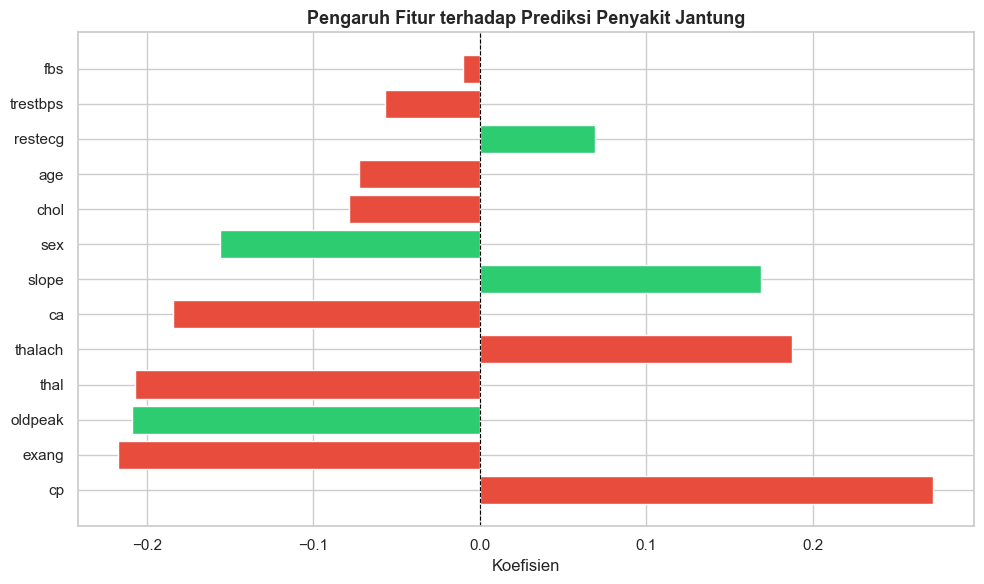

In [17]:
plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefficients]

plt.barh(coef_df['Fitur'], coef_df['Koefisien'], color=colors)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel('Koefisien', fontsize=12)
plt.title('Pengaruh Fitur terhadap Prediksi Penyakit Jantung', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Kesimpulan

**Ringkasan:**
- Model Logistic Regression berhasil memprediksi penyakit jantung dengan akurasi dan AUC-ROC yang baik pada data test.
- Penggunaan **StandardScaler** penting karena Logistic Regression sensitif terhadap skala fitur.
- **Hyperparameter tuning** dengan `GridSearchCV` memastikan model menggunakan parameter regularisasi (`C`) yang optimal.
- Analisis koefisien menunjukkan fitur mana yang paling berkontribusi secara positif/negatif terhadap prediksi.

**Saran pengembangan lebih lanjut:**
- Uji dengan algoritma lain (Random Forest, XGBoost) untuk perbandingan.
- Jika jumlah data memadai, gunakan **K-Fold Cross Validation** yang lebih stabil.
- Eksplorasi **feature engineering** seperti interaksi antar fitur medis.